# Thesis Option Pricing Models — Bloomberg Data

In [95]:
# 0 — CONFIGURATION

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize, differential_evolution
from scipy.integrate import quad
from scipy.special import gammaln
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path('data')
OPTIONS_FILE = DATA_DIR / 'spx_options_bloom.csv'
SPOT_FILE = DATA_DIR / 'spx_spot_history.csv'
OUTPUT_DIR = DATA_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42
N_MC = 100000
MAIN_HORIZON = 0.25 # 3 months, thesis baseline horizon

# Model switches
RUN_MERTON_CALIBRATION = True
RUN_VG_CALIBRATION = True

# Calibration samples:to keep fast/reproducible, then to increase only for final run
MERTON_MAX_OPTIONS = 250
MERTON_N_TERMS = 25
MERTON_MAXITER_GLOBAL = 40
MERTON_POPSIZE = 4
MERTON_TOL = 1e-5
MERTON_MAXITER_LOCAL = 50

VG_MAX_OPTIONS = 80
VG_INTEGRATION_LIMIT = 75
VG_MAXITER_GLOBAL = 20
VG_MAXITER_LOCAL = 50
VG_TOL = 1e-5

np.random.seed(RANDOM_SEED)
print('Configuration loaded.')

Configuration loaded.


## 1 — Load and validate data

In [87]:
# 1 — LOAD DATA

options = pd.read_csv(OPTIONS_FILE)

spot_history = pd.read_csv(SPOT_FILE)

required_cols = {'S0', 'r', 'strike', 'T', 'type', 'mid'}
missing = required_cols.difference(options.columns)
if missing:
    raise ValueError(f'Missing required columns in options file: {missing}')

options['type'] = options['type'].str.lower().str.strip()
options = options.dropna(subset=['S0', 'r', 'strike', 'T', 'type', 'mid']).copy()
options = options[(options['S0'] > 0) & (options['strike'] > 0) & (options['T'] < 2) & (options['mid'] > 0)].copy()

if 'moneyness' not in options.columns:
    options['moneyness'] = options['strike'] / options['S0']
if 'maturity' not in options.columns:
    options['maturity'] = options['T'].round(4).astype(str)
if 'label' not in options.columns:
    options['label'] = options['maturity']

S0 = float(options['S0'].iloc[0])
r = float(options.loc[(options['T'] - MAIN_HORIZON).abs().idxmin(), 'r'])

print(f'Options loaded : {len(options):,}')
print(f'Spot price     : {S0:.2f}')
print(f'r for MC       : {r:.2%}')
print(f'r range        : {options["r"].min():.2%} to {options["r"].max():.2%}')
display(options.groupby(['maturity', 'type'])['strike'].count().unstack())

Options loaded : 1,789
Spot price     : 7383.74
r for MC       : 3.95%
r range        : 3.94% to 4.18%


type,call,put
maturity,,
17-Jun-27,98,165
18-Dec-26,158,170
18-Jun-26,363,373
18-Sep-26,170,292


## 2 — Shared metrics and helpers

In [88]:
# 2 — SHARED FUNCTIONS

def pricing_errors(market, model):
    market = np.asarray(market, dtype=float)
    model = np.asarray(model, dtype=float)
    err = market - model

    rmse = float(np.sqrt(np.mean(err**2)))
    mae = float(np.mean(np.abs(err)))
    mape = float(np.mean(np.abs(err / np.maximum(market, 1e-12))) * 100)

    return {
        'RMSE': rmse, 'MAE': mae, 'MAPE_%': mape }


def compute_tail_risk(returns, levels=(0.95, 0.99), thresholds=(0.05, 0.10, 0.15)):
    #Compute VaR, ES and left-tail exceedance probabilities from simulated returns.
    returns = np.asarray(returns, dtype=float)
    out = {}
    for alpha in levels:
        q = np.percentile(returns, (1 - alpha) * 100)
        var = -q
        tail = returns[returns <= q]
        es = -tail.mean() if len(tail) > 0 else np.nan
        out[f'VaR_{int(alpha * 100)}'] = var
        out[f'ES_{int(alpha * 100)}'] = es
    for threshold in thresholds:
        out[f'P(R<-{int(threshold * 100)}%)'] = float(np.mean(returns < -threshold))
    return out


def add_model_predictions(df, name, prices):
    out = df.copy()
    out[f'price_{name}'] = prices
    out[f'error_{name}'] = out['mid'] - out[f'price_{name}']
    out[f'abs_error_{name}'] = out[f'error_{name}'].abs()
    out[f'rel_error_{name}'] = out[f'abs_error_{name}'] / out['mid']
    return out


def classify_moneyness(df):
    out = df.copy()
    out['moneyness'] = out['strike'] / out['S0']
    out['is_otm'] = (
        ((out['type'] == 'call') & (out['strike'] > out['S0'])) |
        ((out['type'] == 'put') & (out['strike'] < out['S0']))
    )
    return out


def make_calibration_sample(options_df, max_options=250):
    df = classify_moneyness(options_df)

    if len(df) <= max_options:
        return df.copy()

    return df.sample(
        n=max_options,
        random_state=RANDOM_SEED
    ).sort_index()


def diagnostics_by_groups(df, model_name):
    price_col = f'price_{model_name}'
    diag_df = classify_moneyness(df)
    rows = []
    for diagnostic, group_cols in {
        'by_type': ['type'],
        'by_otm': ['is_otm'],
        'by_type_and_otm': ['type', 'is_otm'],
    }.items():
        grouped = (
            diag_df.groupby(group_cols)
            .apply(lambda g: pd.Series(pricing_errors(g['mid'].values, g[price_col].values)))
            .reset_index()
        )
        grouped.insert(0, 'diagnostic', diagnostic)
        rows.append(grouped)
    return pd.concat(rows, ignore_index=True)

print('Shared functions defined.')

def calibration_error(market, model, floor=5.0):
    return (market - model) / np.maximum(market, floor)

Shared functions defined.


In [89]:
# Calibration sample: OTM + ATM, excluding very expensive/deep ITM options
options_calib = options[
    (
        ((options["type"] == "call") & (options["moneyness"] > 1.0)) |
        ((options["type"] == "put") & (options["moneyness"] < 1.0)) |
        ((options["moneyness"] >= 0.95) & (options["moneyness"] <= 1.05))
    )
    &
    (
        (options["T"] <= 2.0)
    )
].copy()

In [90]:
# Stats exactes du dataset complet
print("=== FULL DATASET (options) ===")
summary_full = options.groupby(['maturity', 'type']).agg(
    n          = ('strike', 'count'),
    strike_min = ('strike', 'min'),
    strike_max = ('strike', 'max'),
    iv_min     = ('impliedVolatility', 'min'),
    iv_max     = ('impliedVolatility', 'max'),
).round(4)
display(summary_full)
print(f"Total calls : {(options['type']=='call').sum()}")
print(f"Total puts  : {(options['type']=='put').sum()}")
print(f"Grand total : {len(options)}")

# Stats du dataset de calibration
print("\n=== CALIBRATION SAMPLE (options_calib) ===")
summary_calib = options_calib.groupby(['maturity', 'type']).agg(
    n          = ('strike', 'count'),
    strike_min = ('strike', 'min'),
    strike_max = ('strike', 'max'),
    iv_min     = ('impliedVolatility', 'min'),
    iv_max     = ('impliedVolatility', 'max'),
).round(4)
display(summary_calib)
print(f"Total calls : {(options_calib['type']=='call').sum()}")
print(f"Total puts  : {(options_calib['type']=='put').sum()}")
print(f"Grand total : {len(options_calib)}")

=== FULL DATASET (options) ===


n  strike_min  strike_max  iv_min  iv_max
maturity  type                                             
17-Jun-27 call   98      5000.0     11000.0  0.1363  0.2886
          put   165      3700.0      8500.0  0.1489  0.3920
18-Dec-26 call  158      3700.0     11000.0  0.1334  0.3846
          put   170      3700.0     11000.0  0.1240  0.4627
18-Jun-26 call  363      5750.0      8325.0  0.1273  0.5130
          put   373      5740.0     11000.0  0.1131  0.5726
18-Sep-26 call  170      4000.0     10000.0  0.1297  0.4183
          put   292      3700.0     10800.0  0.1261  0.5543

Total calls : 789
Total puts  : 1000
Grand total : 1789

=== CALIBRATION SAMPLE (options_calib) ===


n  strike_min  strike_max  iv_min  iv_max
maturity  type                                             
17-Jun-27 call   72      7050.0     11000.0  0.1363  0.2032
          put   149      3700.0      7750.0  0.1736  0.3920
18-Dec-26 call   77      7025.0     11000.0  0.1334  0.1999
          put   154      3700.0      7750.0  0.1572  0.4627
18-Jun-26 call  211      7015.0      8325.0  0.1273  0.2367
          put   365      5740.0      7750.0  0.1185  0.5726
18-Sep-26 call  108      7025.0     10000.0  0.1297  0.2063
          put   284      3700.0      7750.0  0.1442  0.5543

Total calls : 468
Total puts  : 952
Grand total : 1420


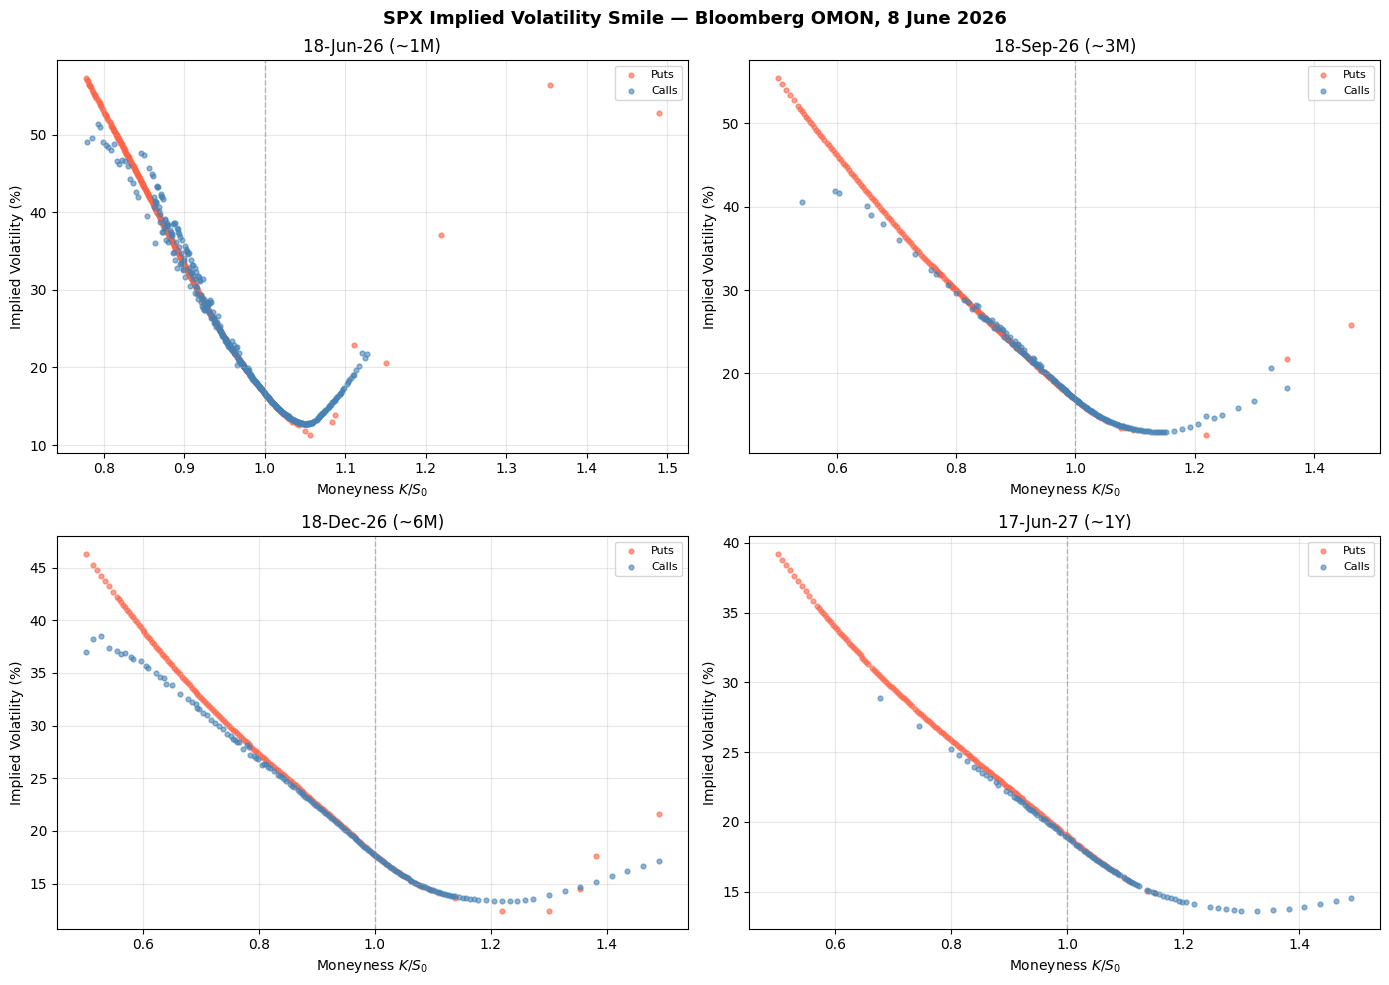

Figure saved: iv_smile.png


In [91]:
# SMILE PLOT — for thesis figure

maturities_ordered = ['18-Jun-26', '18-Sep-26', '18-Dec-26', '17-Jun-27']
labels_ordered     = ['~1M', '~3M', '~6M', '~1Y']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, mat, label in zip(axes, maturities_ordered, labels_ordered):
    subset = options[options['maturity'] == mat]

    calls = subset[subset['type'] == 'call']
    puts  = subset[subset['type'] == 'put']

    ax.scatter(puts['moneyness'],  puts['impliedVolatility']*100,
               s=12, alpha=0.6, color='tomato',    label='Puts')
    ax.scatter(calls['moneyness'], calls['impliedVolatility']*100,
               s=12, alpha=0.6, color='steelblue', label='Calls')

    ax.axvline(1.0, linestyle='--', linewidth=1, color='gray', alpha=0.5)
    ax.set_title(f'{mat} ({label})')
    ax.set_xlabel('Moneyness $K/S_0$')
    ax.set_ylabel('Implied Volatility (%)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('SPX Implied Volatility Smile — Bloomberg OMON, 8 June 2026',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'iv_smile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: iv_smile.png')

## 3 — Black-Scholes

In [ ]:
# 3 — BLACK-SCHOLES PRICING AND CALIBRATION

def bs_call(S0, K, T, r, sigma):
    S0 = np.asarray(S0, dtype=float)
    K = np.asarray(K, dtype=float)
    T = np.asarray(T, dtype=float)
    r = np.asarray(r, dtype=float)
    sigma = float(sigma)
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def bs_put(S0, K, T, r, sigma):
    return bs_call(S0, K, T, r, sigma) - S0 + K * np.exp(-r * T)


def bs_price(S0, K, T, r, sigma, option_type):
    calls = bs_call(S0, K, T, r, sigma)
    puts = bs_put(S0, K, T, r, sigma)
    return np.where(np.asarray(option_type) == 'call', calls, puts)


def calibrate_bs(options_df, relative_errors=True):
    K = options_df['strike'].values
    T = options_df['T'].values
    S = options_df['S0'].values
    rates = options_df['r'].values
    types = options_df['type'].values
    market = options_df['mid'].values

    def objective(x):
        model = bs_price(S, K, T, rates, x[0], types)

        if relative_errors:
            err = calibration_error(market, model)
        else:
            err = market - model

        return np.sum(err**2)

    best = None
    for x0 in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40]:
        res = minimize(objective, [x0], bounds=[(0.01, 3.0)], method='L-BFGS-B')
        if best is None or res.fun < best.fun:
            best = res

    sigma_hat = float(best.x[0])
    model_prices = bs_price(S, K, T, rates, sigma_hat, types)
    metrics = pricing_errors(market, model_prices)
    return sigma_hat, metrics, model_prices, best


print(f"Calibration sample: {len(options_calib)} options")

# BS calibration by maturity

def calibrate_bs_by_maturity(options_df):
    rows = []
    preds = []

    for maturity, subset in options_df.groupby("maturity"):
        sigma_m, metrics_m, prices_m, result_m = calibrate_bs(
            subset,
            relative_errors=True 
        )

        subset_pred = add_model_predictions(subset, "BS", prices_m)
        preds.append(subset_pred)

        rows.append({
            "maturity": maturity,
            "T_mean": subset["T"].mean(),
            "n_options": len(subset),
            "sigma_BS": sigma_m,
            **metrics_m
        })

    return (
        pd.DataFrame(rows).sort_values("T_mean"),
        pd.concat(preds, ignore_index=True)
    )


bs_by_maturity, options_bs = calibrate_bs_by_maturity(options_calib)

sigma_bs = bs_by_maturity["sigma_BS"].median()

bs_metrics = pricing_errors(
    options_bs["mid"].values,
    options_bs["price_BS"].values
)

bs_error_diagnostics = diagnostics_by_groups(options_bs, "BS")

display(bs_by_maturity)
print(f"Sigma BS for Monte Carlo: {sigma_bs:.4f} ({sigma_bs:.2%})")
print(bs_metrics)
display(bs_error_diagnostics)

Calibration sample: 1420 options


,maturity,T_mean,n_options,sigma_BS,RMSE,MAE,MAPE_%
2,18-Jun-26,0.027379,576,0.176548,26.152169,15.545105,60.791727
3,18-Sep-26,0.279261,392,0.152444,36.716891,30.175870,56.987501
1,18-Dec-26,0.528405,231,0.150594,56.692583,45.983641,57.814017
0,17-Jun-27,1.023956,221,0.154995,94.540161,82.942880,56.446294


Sigma BS for Monte Carlo: 0.1537 (15.37%)
{'RMSE': 50.63068772991077, 'MAE': 35.025013520018256, 'MAPE_%': 58.580848002167905}


,diagnostic,type,RMSE,MAE,MAPE_%,is_otm
0,by_type,call,46.960014,31.749873,27.935404,NaN
1,by_type,put,52.340884,36.635062,73.646045,NaN
2,by_otm,NaN,64.658909,57.515764,20.999439,False
3,by_otm,NaN,47.235772,30.404673,66.301307,True
4,by_type_and_otm,call,76.943183,72.405045,19.218382,False
5,by_type_and_otm,call,27.588566,15.946230,31.323920,True
6,by_type_and_otm,put,46.128906,39.943730,23.101408,False
7,by_type_and_otm,put,53.106522,36.198365,80.317216,True


## 3.2 — Black-Scholes smile plot

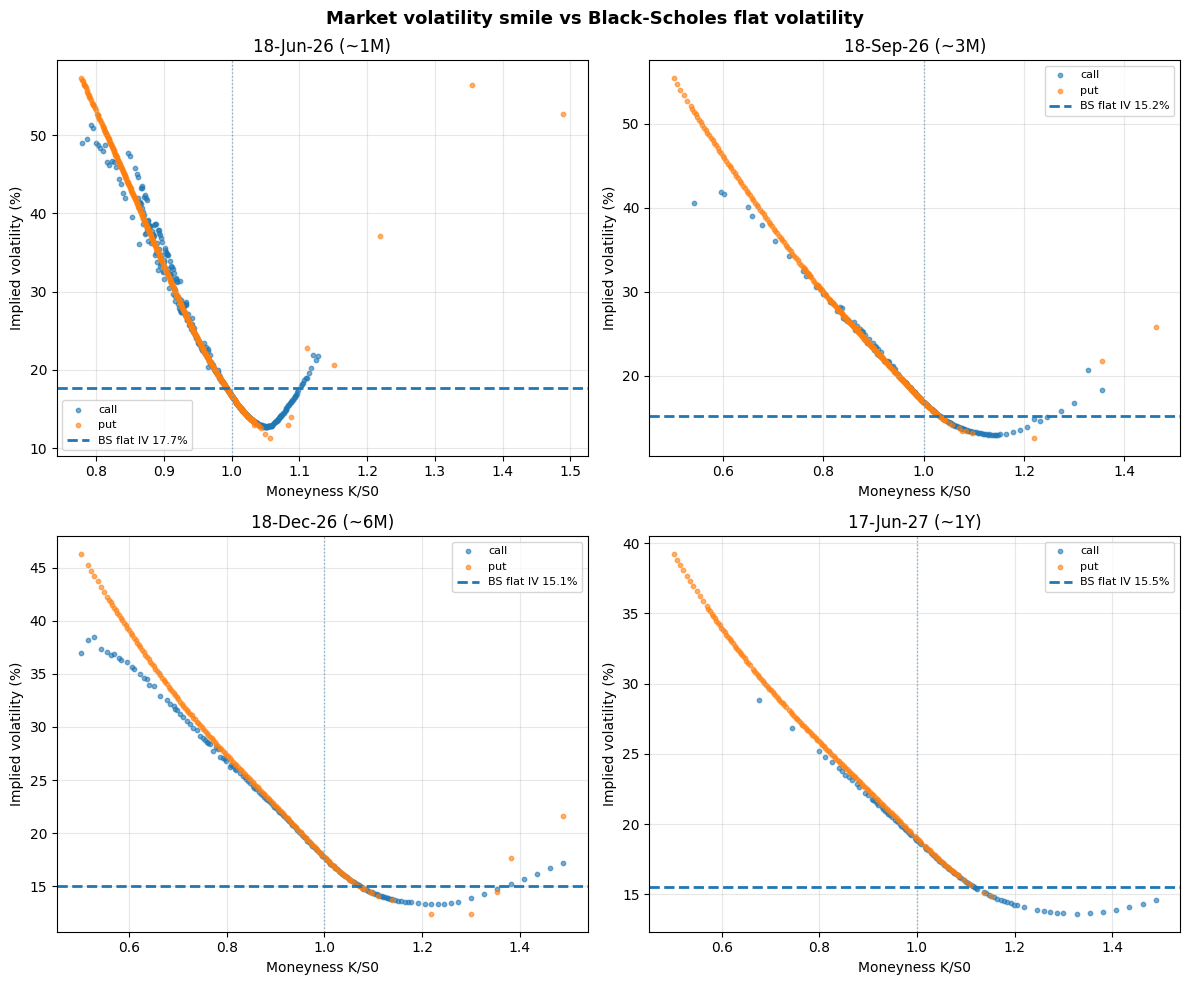

In [117]:
# 3.2 — MARKET SMILE VS BS FLAT VOLATILITY

if 'impliedVolatility' in options.columns:
    mats_to_plot = bs_by_maturity['maturity'].tolist()[:4]
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for ax, maturity in zip(axes, mats_to_plot):
        subset = options[options['maturity'] == maturity]
        sigma_m = float(bs_by_maturity.loc[
            bs_by_maturity['maturity'] == maturity, 'sigma_BS'
        ].iloc[0])
        label = subset['label'].iloc[0]

        for opt_type in ['call', 'put']:
            tmp = subset[subset['type'] == opt_type]
            ax.scatter(tmp['moneyness'], tmp['impliedVolatility'] * 100,
                      s=10, alpha=0.6, label=opt_type)

        ax.axhline(sigma_m * 100, linestyle='--', linewidth=2,
                  label=f'BS flat IV {sigma_m:.1%}')
        ax.axvline(1.0, linestyle=':', linewidth=1, alpha=0.5)
        ax.set_title(f'{maturity} ({label})')
        ax.set_xlabel('Moneyness K/S0')
        ax.set_ylabel('Implied volatility (%)')
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

    plt.suptitle('Market volatility smile vs Black-Scholes flat volatility',
                fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'bs_smile.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Column impliedVolatility not found; smile plot skipped.')

## 4 — Merton Jump-Diffusion

In [94]:
# ============================================================
# 4 — MERTON JUMP-DIFFUSION BY MATURITY
# ============================================================

def merton_call(S0, K, T, r, sigma, lam, mu_J, sigma_J, n_terms=MERTON_N_TERMS):
    kappa = np.exp(mu_J + 0.5 * sigma_J**2) - 1
    price = 0.0
    lamT = max(lam * T, 1e-300)

    for n in range(n_terms):
        log_p = -lam * T + n * np.log(lamT) - gammaln(n + 1)
        p_n = np.exp(log_p)
        sigma_n = np.sqrt(sigma**2 + n * sigma_J**2 / T)
        r_n = r - lam * kappa + n * (mu_J + 0.5 * sigma_J**2) / T
        price += p_n * bs_call(S0, K, T, r_n, sigma_n)

    return price


def merton_price(S0, K, T, r, sigma, lam, mu_J, sigma_J, option_type, n_terms=MERTON_N_TERMS):
    call = merton_call(S0, K, T, r, sigma, lam, mu_J, sigma_J, n_terms=n_terms)
    put = call - S0 + K * np.exp(-r * T)
    return call if option_type == "call" else put


def merton_prices_for_df(options_df, params, n_terms=MERTON_N_TERMS):
    sigma, lam, mu_J, sigma_J = params

    return np.array([
        merton_price(
            row.S0,
            row.strike,
            row.T,
            row.r,
            sigma,
            lam,
            mu_J,
            sigma_J,
            row.type,
            n_terms=n_terms
        )
        for row in options_df.itertuples(index=False)
    ])


def calibrate_merton(options_df, n_terms=MERTON_N_TERMS):
    market = options_df["mid"].values

    def objective(params):
        model = merton_prices_for_df(options_df, params, n_terms=n_terms)
        err = calibration_error(market, model)
        return np.sum(err**2)

    bounds = [
        (0.03, 0.60),     # sigma
        (0.01, 5.00),     # lambda
        (-0.40, 0.05),    # mu_J
        (0.02, 0.60),     # sigma_J
    ]

    global_result = differential_evolution(
        objective,
        bounds=bounds,
        seed=RANDOM_SEED,
        maxiter=MERTON_MAXITER_GLOBAL,
        popsize=MERTON_POPSIZE,
        tol=MERTON_TOL,
        polish=False,
        workers=1,
        updating="immediate",
    )

    local_result = minimize(
        objective,
        x0=global_result.x,
        bounds=bounds,
        method="L-BFGS-B",
        options={"maxiter": MERTON_MAXITER_LOCAL},
    )

    params_hat = local_result.x
    model_prices = merton_prices_for_df(options_df, params_hat, n_terms=n_terms)
    metrics = pricing_errors(market, model_prices)

    return params_hat, metrics, model_prices, local_result


if RUN_MERTON_CALIBRATION:

    options_model = options_calib[
        options_calib["T"] < 2
    ].copy()

    merton_rows = []
    merton_preds = []

    for maturity, subset in options_model.groupby("maturity"):

        subset_sample = make_calibration_sample(
            subset,
            max_options=min(MERTON_MAX_OPTIONS, len(subset))
        )

        print(
            f"Merton {maturity}: calibrating on "
            f"{len(subset_sample)} options, n_terms={MERTON_N_TERMS}"
        )

        params_m, metrics_m_calib, _, result_m = calibrate_merton(
            subset_sample,
            n_terms=MERTON_N_TERMS
        )

        prices_m = merton_prices_for_df(
            subset,
            params_m,
            n_terms=MERTON_N_TERMS
        )

        metrics_m_full = pricing_errors(
            subset["mid"].values,
            prices_m
        )

        subset_pred = add_model_predictions(
            subset,
            "Merton",
            prices_m
        )

        merton_preds.append(subset_pred)

        merton_rows.append({
            "maturity": maturity,
            "T_mean": subset["T"].mean(),
            "n_options": len(subset),
            "sigma": params_m[0],
            "lambda": params_m[1],
            "mu_J": params_m[2],
            "sigma_J": params_m[3],
            "RMSE_calib": metrics_m_calib["RMSE"],
            "MAE_calib": metrics_m_calib["MAE"],
            "MAPE_calib_%": metrics_m_calib["MAPE_%"],
            "RMSE": metrics_m_full["RMSE"],
            "MAE": metrics_m_full["MAE"],
            "MAPE_%": metrics_m_full["MAPE_%"],
        })

    merton_by_maturity = pd.DataFrame(merton_rows).sort_values("T_mean")

    options_merton = pd.concat(
        merton_preds,
        ignore_index=True
    )

    merton_metrics = pricing_errors(
        options_merton["mid"].values,
        options_merton["price_Merton"].values
    )

    merton_error_diagnostics = diagnostics_by_groups(
        options_merton,
        "Merton"
    )

    display(merton_by_maturity)
    print("Merton full clean-sample metrics:", merton_metrics)
    display(merton_error_diagnostics)

    merton_params = np.array([
        merton_by_maturity["sigma"].median(),
        merton_by_maturity["lambda"].median(),
        merton_by_maturity["mu_J"].median(),
        merton_by_maturity["sigma_J"].median(),
    ])

    print("Merton parameters for Monte Carlo, median by maturity:")
    print(f"  sigma   = {merton_params[0]:.4f}")
    print(f"  lambda  = {merton_params[1]:.4f}")
    print(f"  mu_J    = {merton_params[2]:.4f}")
    print(f"  sigma_J = {merton_params[3]:.4f}")

else:
    print("Merton calibration skipped.")

Merton 17-Jun-27: calibrating on 221 options, n_terms=25
Merton 18-Dec-26: calibrating on 231 options, n_terms=25
Merton 18-Jun-26: calibrating on 250 options, n_terms=25
Merton 18-Sep-26: calibrating on 250 options, n_terms=25


,maturity,T_mean,n_options,sigma,lambda,mu_J,sigma_J,RMSE_calib,MAE_calib,MAPE_calib_%,RMSE,MAE,MAPE_%
2,18-Jun-26,0.027379,576,0.159307,0.319065,-0.187853,0.149001,26.851161,15.643088,19.938971,24.862036,13.495391,19.870733
3,18-Sep-26,0.279261,392,0.117670,0.089916,-0.400000,0.472581,30.443584,20.784876,36.309270,30.746408,21.481591,37.106314
1,18-Dec-26,0.528405,231,0.116011,0.088690,-0.400000,0.425783,45.044967,35.889249,55.398606,45.044967,35.889249,55.398606
0,17-Jun-27,1.023956,221,0.109838,0.095610,-0.400000,0.427907,71.516854,63.912770,41.716954,71.516854,63.912770,41.716954


Merton full clean-sample metrics: {'RMSE': 40.469618237753224, 'MAE': 27.18962491572083, 'MAPE_%': 33.808269080409964}


,diagnostic,type,RMSE,MAE,MAPE_%,is_otm
0,by_type,call,50.205992,36.696364,45.650754,NaN
1,by_type,put,34.695577,22.516144,27.986543,NaN
2,by_otm,NaN,63.252819,57.015794,20.552212,False
3,by_otm,NaN,33.945919,21.062347,36.531500,True
4,by_type_and_otm,call,73.659666,70.462859,19.102576,False
5,by_type_and_otm,call,37.300906,23.570516,55.970669,True
6,by_type_and_otm,put,48.159799,41.145834,22.263043,False
7,by_type_and_otm,put,32.504493,20.057290,28.741964,True


Merton parameters for Monte Carlo, median by maturity:
  sigma   = 0.1168
  lambda  = 0.0928
  mu_J    = -0.4000
  sigma_J = 0.4268


## 5 — Variance Gamma

In [96]:
# 5 — VARIANCE GAMMA PRICING BY MATURITY

def vg_omega(sigma, nu, theta):
    condition = 1 - theta * nu - 0.5 * sigma**2 * nu
    if condition <= 0:
        raise ValueError("Invalid VG parameters.")
    return np.log(condition) / nu


def vg_log_cf(u, S0, T, r, sigma, nu, theta):
    omega = vg_omega(sigma, nu, theta)
    iu = 1j * u
    log_S0 = np.log(S0)
    drift = iu * (log_S0 + (r + omega) * T)
    vg_part = -(T / nu) * np.log(
        1 - iu * theta * nu + 0.5 * sigma**2 * nu * u**2
    )
    return np.exp(drift + vg_part)


def vg_call_carr_madan(
    S0, K, T, r, sigma, nu, theta,
    alpha=1.5,
    integration_limit=VG_INTEGRATION_LIMIT
):
    k = np.log(K)

    def integrand(v):
        u = v - 1j * (alpha + 1)
        numerator = np.exp(-r * T) * vg_log_cf(
            u, S0, T, r, sigma, nu, theta
        )
        denominator = (
            alpha**2 + alpha - v**2 + 1j * (2 * alpha + 1) * v
        )
        return np.real(
            np.exp(-1j * v * k) * numerator / denominator
        )

    integral, _ = quad(
        integrand,
        0,
        integration_limit,
        limit=100
    )

    return np.exp(-alpha * k) * integral / np.pi


def vg_price(S0, K, T, r, sigma, nu, theta, option_type):
    call = vg_call_carr_madan(S0, K, T, r, sigma, nu, theta)
    put = call - S0 + K * np.exp(-r * T)
    return call if option_type == "call" else put


def vg_prices_for_df(options_df, params):
    sigma, nu, theta = params

    return np.array([
        vg_price(
            row.S0,
            row.strike,
            row.T,
            row.r,
            sigma,
            nu,
            theta,
            row.type
        )
        for row in options_df.itertuples(index=False)
    ])


def calibrate_vg(options_df):
    market = options_df["mid"].values

    def objective(params):
        sigma, nu, theta = params

        if sigma <= 0 or nu <= 0:
            return 1e12

        if 1 - theta * nu - 0.5 * sigma**2 * nu <= 0:
            return 1e12

        try:
            model = vg_prices_for_df(options_df, params)

            if np.any(~np.isfinite(model)):
                return 1e12

            err = calibration_error(market, model)
            return np.sum(err**2)

        except Exception:
            return 1e12

    bounds = [
        (0.03, 0.80),    # sigma
        (0.01, 4.00),    # nu
        (-1.00, 0.20),   # theta
    ]

    global_result = differential_evolution(
        objective,
        bounds=bounds,
        seed=RANDOM_SEED,
        maxiter=VG_MAXITER_GLOBAL,
        tol=VG_TOL,
        polish=False,
        workers=1,
    )

    local_result = minimize(
        objective,
        x0=global_result.x,
        bounds=bounds,
        method="L-BFGS-B",
        options={"maxiter": VG_MAXITER_LOCAL},
    )

    params_hat = local_result.x
    model_prices = vg_prices_for_df(options_df, params_hat)
    metrics = pricing_errors(market, model_prices)

    return params_hat, metrics, model_prices, local_result


if RUN_VG_CALIBRATION:

    options_model = options_calib[
        options_calib["T"] < 2
    ].copy()

    vg_rows = []
    vg_preds = []

    for maturity, subset in options_model.groupby("maturity"):

        subset_sample = make_calibration_sample(
            subset,
            max_options=min(VG_MAX_OPTIONS, len(subset))
        )

        print(
            f"VG {maturity}: calibrating on "
            f"{len(subset_sample)} options, "
            f"integration_limit={VG_INTEGRATION_LIMIT}"
        )

        params_v, metrics_v_calib, _, result_v = calibrate_vg(
            subset_sample
        )

        prices_v = vg_prices_for_df(
            subset,
            params_v
        )

        metrics_v_full = pricing_errors(
            subset["mid"].values,
            prices_v
        )

        subset_pred = add_model_predictions(
            subset,
            "VG",
            prices_v
        )

        vg_preds.append(subset_pred)

        vg_rows.append({
            "maturity": maturity,
            "T_mean": subset["T"].mean(),
            "n_options": len(subset),
            "sigma": params_v[0],
            "nu": params_v[1],
            "theta": params_v[2],
            "RMSE_calib": metrics_v_calib["RMSE"],
            "MAE_calib": metrics_v_calib["MAE"],
            "MAPE_calib_%": metrics_v_calib["MAPE_%"],
            "RMSE": metrics_v_full["RMSE"],
            "MAE": metrics_v_full["MAE"],
            "MAPE_%": metrics_v_full["MAPE_%"],
        })

    vg_by_maturity = pd.DataFrame(
        vg_rows
    ).sort_values("T_mean")

    options_vg = pd.concat(
        vg_preds,
        ignore_index=True
    )

    vg_metrics = pricing_errors(
        options_vg["mid"].values,
        options_vg["price_VG"].values
    )

    vg_error_diagnostics = diagnostics_by_groups(
        options_vg,
        "VG"
    )

    display(vg_by_maturity)
    print("VG full clean-sample metrics:", vg_metrics)
    display(vg_error_diagnostics)

    vg_params = np.array([
        vg_by_maturity["sigma"].median(),
        vg_by_maturity["nu"].median(),
        vg_by_maturity["theta"].median(),
    ])

    print("VG parameters for Monte Carlo, median by maturity:")
    print(f"  sigma = {vg_params[0]:.4f}")
    print(f"  nu    = {vg_params[1]:.4f}")
    print(f"  theta = {vg_params[2]:.4f}")

else:
    print("VG calibration skipped.")

VG 17-Jun-27: calibrating on 80 options, integration_limit=75
VG 18-Dec-26: calibrating on 80 options, integration_limit=75
VG 18-Jun-26: calibrating on 80 options, integration_limit=75
VG 18-Sep-26: calibrating on 80 options, integration_limit=75


,maturity,T_mean,n_options,sigma,nu,theta,RMSE_calib,MAE_calib,MAPE_calib_%,RMSE,MAE,MAPE_%
2,18-Jun-26,0.027379,576,0.181483,0.027382,-0.583068,25.199501,16.544456,64.242123,22.529122,13.954918,64.974474
3,18-Sep-26,0.279261,392,0.160982,1.246166,-0.126193,27.352853,18.370600,21.777359,24.436287,16.105089,21.615848
1,18-Dec-26,0.528405,231,0.157464,1.425851,-0.141419,16.502075,11.779592,12.638831,19.622344,14.186255,14.968638
0,17-Jun-27,1.023956,221,0.164773,1.940076,-0.130820,14.711623,11.677120,7.234966,15.662010,12.858905,7.826244


VG full clean-sample metrics: {'RMSE': 21.71495096101339, 'MAE': 14.415543013121473, 'MAPE_%': 35.97610187324168}


,diagnostic,type,RMSE,MAE,MAPE_%,is_otm
0,by_type,call,31.267325,23.254594,47.602527,NaN
1,by_type,put,14.924438,10.070295,30.260591,NaN
2,by_otm,NaN,36.945087,33.820706,16.293127,False
3,by_otm,NaN,16.970717,10.429083,40.019633,True
4,by_type_and_otm,call,38.892558,36.482494,12.132558,False
5,by_type_and_otm,call,27.743177,18.112592,61.390556,True
6,by_type_and_otm,put,34.505605,30.679317,21.203348,False
7,by_type_and_otm,put,9.746288,7.350198,31.456017,True


VG parameters for Monte Carlo, median by maturity:
  sigma = 0.1629
  nu    = 1.3360
  theta = -0.1361


##  6 - Final Comparison Table 

In [97]:
comparison_table = pd.DataFrame([
    {
        "Model": "Black-Scholes",
        "Sigma": sigma_bs,
        "Lambda": np.nan,
        "Mu_J": np.nan,
        "Sigma_J": np.nan,
        "Nu": np.nan,
        "Theta": np.nan,
        "RMSE": bs_metrics["RMSE"],
        "MAE": bs_metrics["MAE"],
        "MAPE_%": bs_metrics["MAPE_%"],
    },
    {
        "Model": "Merton",
        "Sigma": merton_params[0],
        "Lambda": merton_params[1],
        "Mu_J": merton_params[2],
        "Sigma_J": merton_params[3],
        "Nu": np.nan,
        "Theta": np.nan,
        "RMSE": merton_metrics["RMSE"],
        "MAE": merton_metrics["MAE"],
        "MAPE_%": merton_metrics["MAPE_%"],
    },
    {
        "Model": "Variance Gamma",
        "Sigma": vg_params[0],
        "Lambda": np.nan,
        "Mu_J": np.nan,
        "Sigma_J": np.nan,
        "Nu": vg_params[1],
        "Theta": vg_params[2],
        "RMSE": vg_metrics["RMSE"],
        "MAE": vg_metrics["MAE"],
        "MAPE_%": vg_metrics["MAPE_%"],
    },
])

display(comparison_table.round(4))

,Model,Sigma,Lambda,Mu_J,Sigma_J,Nu,Theta,RMSE,MAE,MAPE_%
0,Black-Scholes,0.1537,NaN,NaN,NaN,NaN,NaN,50.6307,35.0250,58.5808
1,Merton,0.1168,0.0928,-0.4,0.4268,NaN,NaN,40.4696,27.1896,33.8083
2,Variance Gamma,0.1629,NaN,NaN,NaN,1.336,-0.1361,21.7150,14.4155,35.9761


## 7 - Market price vs Model price

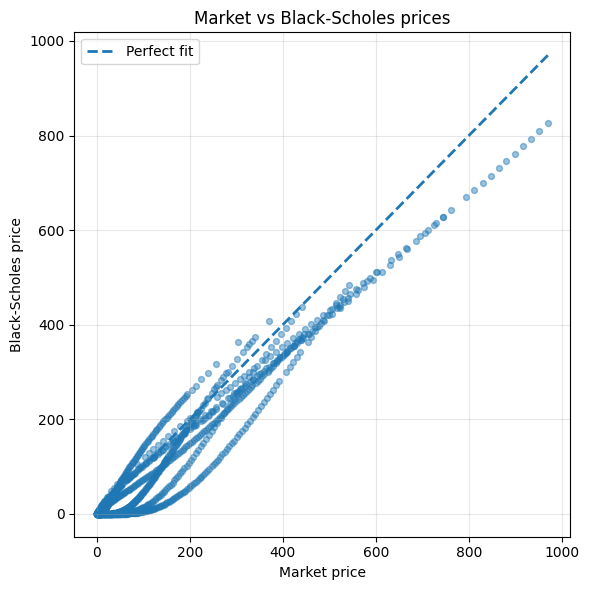

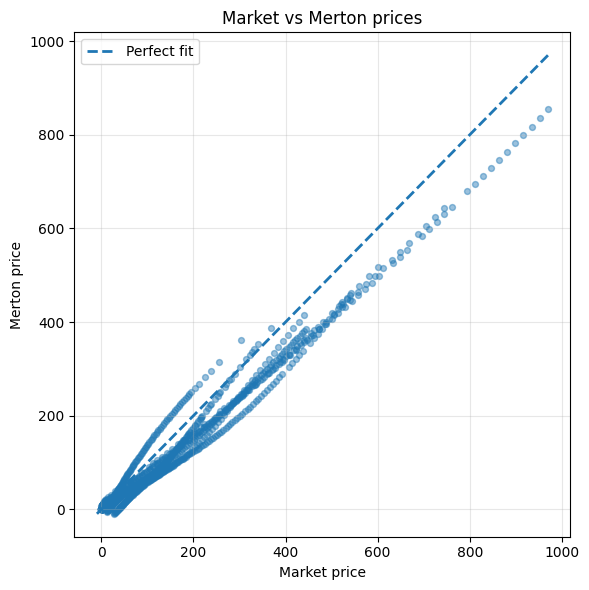

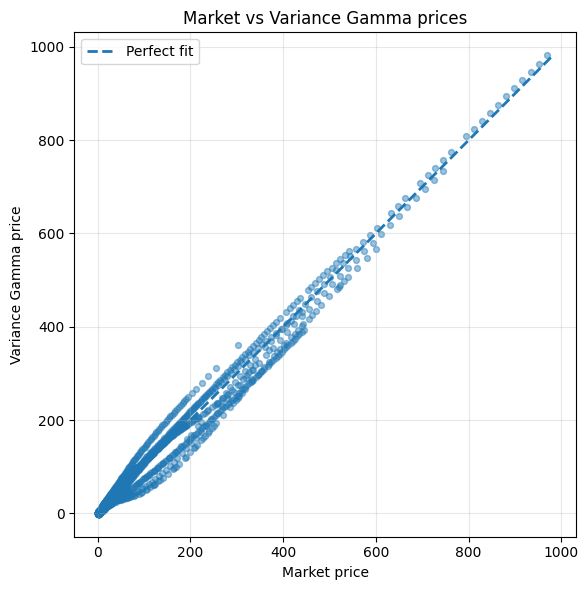

In [118]:
plot_df = (
    options_bs[["mid", "price_BS", "maturity", "type"]]
    .merge(
        options_merton[["mid", "price_Merton", "maturity", "type"]],
        left_index=True,
        right_index=True,
        suffixes=("", "_merton")
    )
    .merge(
        options_vg[["mid", "price_VG", "maturity", "type"]],
        left_index=True,
        right_index=True,
        suffixes=("", "_vg")
    )
)

models_to_plot = {
    "Black-Scholes": "price_BS",
    "Merton": "price_Merton",
    "Variance Gamma": "price_VG",
}

for model_name, price_col in models_to_plot.items():

    plt.figure(figsize=(6, 6))

    plt.scatter(
        plot_df["mid"],
        plot_df[price_col],
        alpha=0.45,
        s=18
    )

    min_price = min(plot_df["mid"].min(), plot_df[price_col].min())
    max_price = max(plot_df["mid"].max(), plot_df[price_col].max())

    plt.plot(
        [min_price, max_price],
        [min_price, max_price],
        linestyle="--",
        linewidth=2,
        label="Perfect fit"
    )

    plt.xlabel("Market price")
    plt.ylabel(f"{model_name} price")
    plt.title(f"Market vs {model_name} prices")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / f"market_vs_model_{model_name.replace(' ', '_')}.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

## 8 - Risk-neutral simulated return distributions

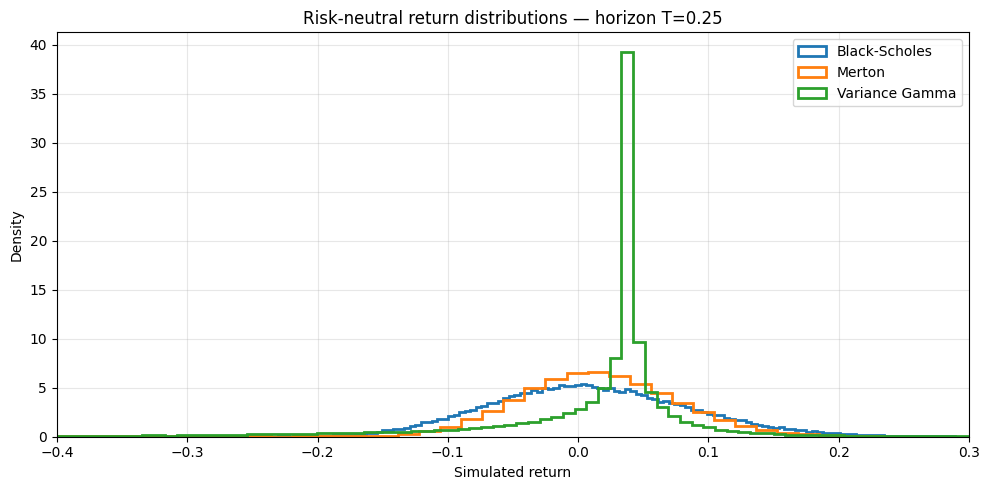

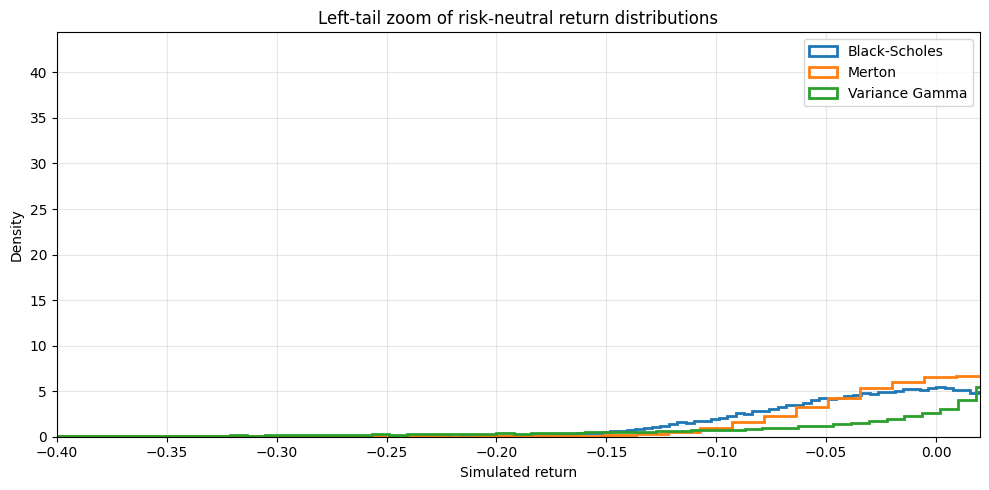

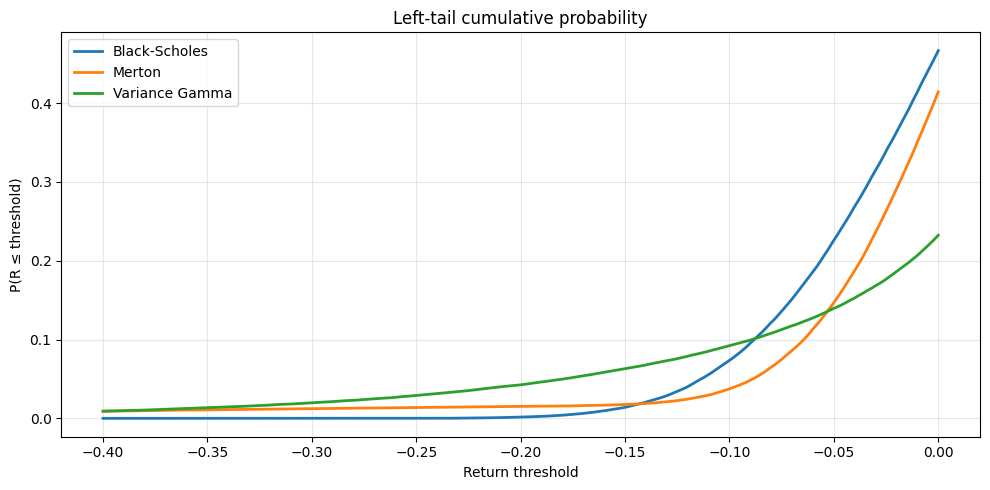

In [107]:
def simulate_bs_returns(S0, T, r, sigma, n_mc=N_MC, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    Z = rng.normal(size=n_mc)

    log_return = (
        (r - 0.5 * sigma**2) * T
        + sigma * np.sqrt(T) * Z
    )

    return np.exp(log_return) - 1


def simulate_merton_returns(S0, T, r, params, n_mc=N_MC, seed=RANDOM_SEED):
    sigma, lam, mu_J, sigma_J = params
    rng = np.random.default_rng(seed)

    kappa = np.exp(mu_J + 0.5 * sigma_J**2) - 1

    Z = rng.normal(size=n_mc)
    N = rng.poisson(lam * T, size=n_mc)

    jump_sum = np.array([
        rng.normal(mu_J, sigma_J, n).sum() if n > 0 else 0.0
        for n in N
    ])

    log_return = (
        (r - 0.5 * sigma**2 - lam * kappa) * T
        + sigma * np.sqrt(T) * Z
        + jump_sum
    )

    return np.exp(log_return) - 1


def simulate_vg_returns(S0, T, r, params, n_mc=N_MC, seed=RANDOM_SEED):
    sigma, nu, theta = params
    rng = np.random.default_rng(seed)

    omega = vg_omega(sigma, nu, theta)

    G = rng.gamma(
        shape=T / nu,
        scale=nu,
        size=n_mc
    )

    Z = rng.normal(size=n_mc)

    log_return = (
        (r + omega) * T
        + theta * G
        + sigma * np.sqrt(G) * Z
    )

    return np.exp(log_return) - 1


# ------------------------------------------------------------
# Simulate returns
# ------------------------------------------------------------

returns_bs = simulate_bs_returns(S0, MAIN_HORIZON, r, sigma_bs)
returns_merton = simulate_merton_returns(S0, MAIN_HORIZON, r, merton_params)
returns_vg = simulate_vg_returns(S0, MAIN_HORIZON, r, vg_params)

returns_dict = {
    "Black-Scholes": returns_bs,
    "Merton": returns_merton,
    "Variance Gamma": returns_vg,
}


# ------------------------------------------------------------
# Plot 1 — Full distribution, step histogram
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

for model_name, returns in returns_dict.items():
    plt.hist(
        returns,
        bins=180,
        density=True,
        histtype="step",
        linewidth=2,
        label=model_name
    )

plt.xlim(-0.40, 0.30)
plt.xlabel("Simulated return")
plt.ylabel("Density")
plt.title(f"Risk-neutral return distributions — horizon T={MAIN_HORIZON}")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "risk_neutral_return_distributions_step.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Plot 2 — Left-tail zoom
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

for model_name, returns in returns_dict.items():
    plt.hist(
        returns,
        bins=200,
        density=True,
        histtype="step",
        linewidth=2,
        label=model_name
    )

plt.xlim(-0.40, 0.02)
plt.xlabel("Simulated return")
plt.ylabel("Density")
plt.title("Left-tail zoom of risk-neutral return distributions")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "risk_neutral_left_tail_zoom.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Plot 3 — Left-tail cumulative probabilities
# ------------------------------------------------------------

thresholds = np.linspace(-0.40, 0.00, 200)

plt.figure(figsize=(10, 5))

for model_name, returns in returns_dict.items():
    probs = [np.mean(returns <= x) for x in thresholds]

    plt.plot(
        thresholds,
        probs,
        linewidth=2,
        label=model_name
    )

plt.xlabel("Return threshold")
plt.ylabel("P(R ≤ threshold)")
plt.title("Left-tail cumulative probability")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "left_tail_cumulative_probability.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [108]:
tail_probs = []

for model_name, returns in returns_dict.items():
    tail_probs.append({
        "Model": model_name,
        "P(R < -5%)": np.mean(returns < -0.05),
        "P(R < -10%)": np.mean(returns < -0.10),
        "P(R < -20%)": np.mean(returns < -0.20),
        "P(R < -30%)": np.mean(returns < -0.30),
        "P(R < -40%)": np.mean(returns < -0.40),
    })

tail_probs_table = pd.DataFrame(tail_probs)
display(tail_probs_table.round(4))

,Model,P(R < -5%),P(R < -10%),P(R < -20%),P(R < -30%),P(R < -40%)
0,Black-Scholes,0.2260,0.0734,0.0016,0.0000,0.0000
1,Merton,0.1468,0.0375,0.0152,0.0122,0.0091
2,Variance Gamma,0.1395,0.0922,0.0426,0.0197,0.0091


## 9 — Monte Carlo simulations and tail risk

In [ ]:
risk_table = pd.DataFrame([
    {"Model": model_name, **compute_tail_risk(returns)}
    for model_name, returns in returns_by_model.items()
])

display(risk_table.round(4))

risk_table.to_csv(
    OUTPUT_DIR / "tail_risk_monte_carlo.csv",
    index=False
)

,Model,VaR_95,ES_95,VaR_99,ES_99,P(R<-5%),P(R<-10%),P(R<-15%)
0,Black-Scholes,0.1136,0.1410,0.1590,0.1807,0.2260,0.0734,0.0140
1,Merton,0.0889,0.2133,0.3737,0.5262,0.1468,0.0375,0.0175
2,Variance Gamma,0.1792,0.3049,0.3868,0.4968,0.1395,0.0922,0.0629


## 10 — Realised VAR across multiple maturities

In [110]:

def detect_date_column(df):
    for col in ["Date", "date", "timestamp", "Datetime", "datetime"]:
        if col in df.columns:
            return col
    raise ValueError(f"No date column found. Columns: {list(df.columns)}")


def detect_price_column(df):
    for col in ["Close", "close", "PX_LAST", "last", "price", "Adj Close", "S0"]:
        if col in df.columns:
            return col
    raise ValueError(f"No price column found. Columns: {list(df.columns)}")


def realised_var_es(spot_df, alpha=0.99, lookback_days=63):
    date_col = detect_date_column(spot_df)
    price_col = detect_price_column(spot_df)

    df = spot_df[[date_col, price_col]].dropna().copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col)

    df["return"] = df[price_col].pct_change()
    returns = df["return"].dropna().tail(lookback_days)

    q = np.percentile(returns, (1 - alpha) * 100)
    var = -q
    es = -returns[returns <= q].mean()

    return var, es


windows = {
    "1M": 21,
    "3M": 63,
    "6M": 126,
    "1Y": 252,
}

realised_rows = []

for window_name, days in windows.items():
    var95, es95 = realised_var_es(spot_history, alpha=0.95, lookback_days=days)
    var99, es99 = realised_var_es(spot_history, alpha=0.99, lookback_days=days)

    realised_rows.append({
        "Window": window_name,
        "Days": days,
        "Realised_VaR_95": var95,
        "Realised_ES_95": es95,
        "Realised_VaR_99": var99,
        "Realised_ES_99": es99,
    })

realised_var_table = pd.DataFrame(realised_rows)
display(realised_var_table.round(4))

,Window,Days,Realised_VaR_95,Realised_ES_95,Realised_VaR_99,Realised_ES_99
0,1M,21,0.0124,0.0194,0.0236,0.0264
1,3M,63,0.0152,0.0190,0.0208,0.0264
2,6M,126,0.0148,0.0182,0.0198,0.0235
3,1Y,252,0.0128,0.0176,0.0190,0.0247


In [111]:
# MODEL 3M VAR VS REALISED 3M VAR

def get_clean_spot_returns_3m(spot_df, horizon_days=63):
    date_col = detect_date_column(spot_df)
    price_col = detect_price_column(spot_df)

    df = spot_df[[date_col, price_col]].dropna().copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col)

    df["return_3m_forward"] = df[price_col].shift(-horizon_days) / df[price_col] - 1

    return df.dropna(subset=["return_3m_forward"])


def realised_var_es_from_returns(returns, alpha=0.99):
    returns = np.asarray(returns, dtype=float)

    q = np.percentile(returns, (1 - alpha) * 100)
    var = -q
    es = -returns[returns <= q].mean()

    return var, es


# Build realised 3M forward returns
spot_3m = get_clean_spot_returns_3m(
    spot_history,
    horizon_days=63
)

windows = {
    "1Y": 252,
    "2Y": 504,
    "3Y": 756,
    "Full": len(spot_3m),
}

realised_rows = []

for window_name, n_obs in windows.items():
    sample = spot_3m["return_3m_forward"].tail(n_obs)

    var95, es95 = realised_var_es_from_returns(sample, alpha=0.95)
    var99, es99 = realised_var_es_from_returns(sample, alpha=0.99)

    realised_rows.append({
        "Window": window_name,
        "N_obs": len(sample),
        "Realised_3M_VaR_95": var95,
        "Realised_3M_ES_95": es95,
        "Realised_3M_VaR_99": var99,
        "Realised_3M_ES_99": es99,
    })

realised_3m_var_table = pd.DataFrame(realised_rows)
display(realised_3m_var_table.round(4))


# Compare model-implied 3M VaR with realised 3M VaR
model_var_3m = risk_table[["Model", "VaR_95", "ES_95", "VaR_99", "ES_99"]].copy()
model_var_3m = model_var_3m.rename(columns={
    "VaR_95": "Model_3M_VaR_95",
    "ES_95": "Model_3M_ES_95",
    "VaR_99": "Model_3M_VaR_99",
    "ES_99": "Model_3M_ES_99",
})

comparison_rows = []

for _, real_row in realised_3m_var_table.iterrows():
    for _, model_row in model_var_3m.iterrows():
        comparison_rows.append({
            "Window": real_row["Window"],
            "N_obs": real_row["N_obs"],
            "Model": model_row["Model"],

            "Model_3M_VaR_95": model_row["Model_3M_VaR_95"],
            "Realised_3M_VaR_95": real_row["Realised_3M_VaR_95"],
            "Abs_Error_VaR_95": abs(model_row["Model_3M_VaR_95"] - real_row["Realised_3M_VaR_95"]),

            "Model_3M_VaR_99": model_row["Model_3M_VaR_99"],
            "Realised_3M_VaR_99": real_row["Realised_3M_VaR_99"],
            "Abs_Error_VaR_99": abs(model_row["Model_3M_VaR_99"] - real_row["Realised_3M_VaR_99"]),
        })

var_validation_3m_table = pd.DataFrame(comparison_rows)
display(var_validation_3m_table.round(4))

var_validation_3m_table.to_csv(
    OUTPUT_DIR / "model_vs_realised_3m_var_validation.csv",
    index=False
)

,Window,N_obs,Realised_3M_VaR_95,Realised_3M_ES_95,Realised_3M_VaR_99,Realised_3M_ES_99
0,1Y,252,0.0289,0.0481,0.0585,0.0761
1,2Y,504,0.0757,0.0988,0.1166,0.1387
2,3Y,756,0.0700,0.0925,0.1100,0.1320
3,Full,5327,0.1059,0.1750,0.2423,0.2919


,Window,N_obs,Model,Model_3M_VaR_95,Realised_3M_VaR_95,Abs_Error_VaR_95,Model_3M_VaR_99,Realised_3M_VaR_99,Abs_Error_VaR_99
0,1Y,252,Black-Scholes,0.1136,0.0289,0.0847,0.1590,0.0585,0.1005
1,1Y,252,Merton,0.0889,0.0289,0.0600,0.3737,0.0585,0.3151
2,1Y,252,Variance Gamma,0.1792,0.0289,0.1503,0.3868,0.0585,0.3282
3,2Y,504,Black-Scholes,0.1136,0.0757,0.0379,0.1590,0.1166,0.0424
4,2Y,504,Merton,0.0889,0.0757,0.0132,0.3737,0.1166,0.2570
5,2Y,504,Variance Gamma,0.1792,0.0757,0.1036,0.3868,0.1166,0.2701
6,3Y,756,Black-Scholes,0.1136,0.0700,0.0435,0.1590,0.1100,0.0490
7,3Y,756,Merton,0.0889,0.0700,0.0188,0.3737,0.1100,0.2636
8,3Y,756,Variance Gamma,0.1792,0.0700,0.1092,0.3868,0.1100,0.2767
9,Full,5327,Black-Scholes,0.1136,0.1059,0.0077,0.1590,0.2423,0.0832


In [120]:
# VAR Accuracy

var_ranking = (
    var_validation_3m_table
    .groupby("Model")
    .agg({
        "Abs_Error_VaR_95": "mean",
        "Abs_Error_VaR_99": "mean"
    })
    .reset_index()
)

var_ranking["Average_Error"] = (
    var_ranking["Abs_Error_VaR_95"]
    + var_ranking["Abs_Error_VaR_99"]
) / 2

var_ranking = var_ranking.sort_values("Average_Error")

display(var_ranking.round(4))

,Model,Abs_Error_VaR_95,Abs_Error_VaR_99,Average_Error
0,Black-Scholes,0.0434,0.0688,0.0561
1,Merton,0.0273,0.2418,0.1345
2,Variance Gamma,0.1091,0.2549,0.1820


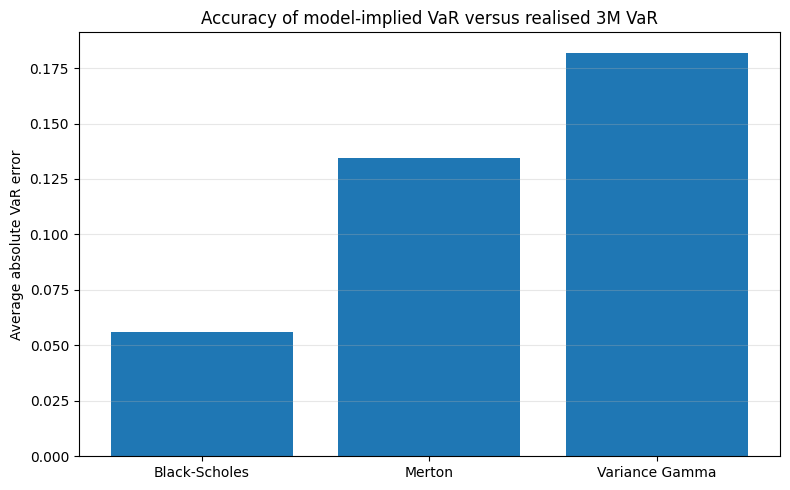

In [113]:
plt.figure(figsize=(8,5))

plt.bar(
    var_ranking["Model"],
    var_ranking["Average_Error"]
)

plt.ylabel("Average absolute VaR error")
plt.title("Accuracy of model-implied VaR versus realised 3M VaR")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

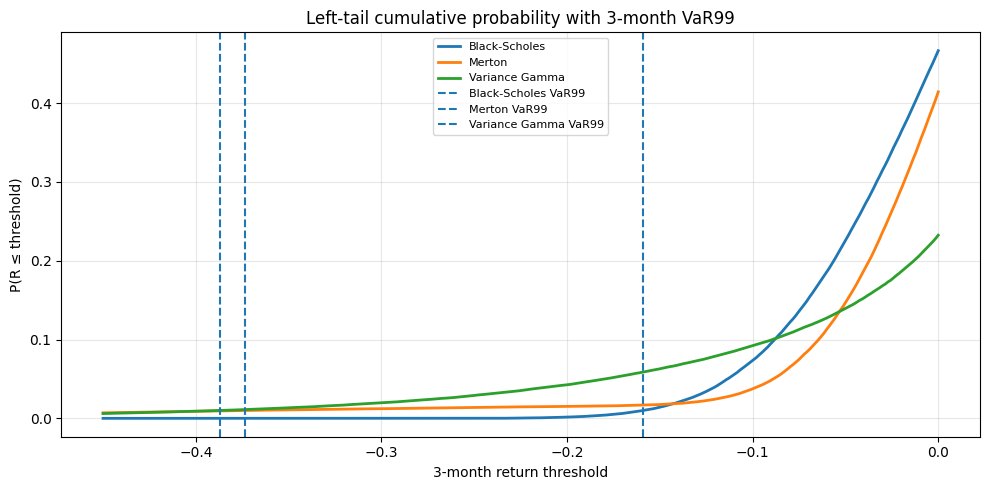

In [114]:
# ------------------------------------------------------------
# Plot 3 — Left-tail cumulative probabilities with VaR99
# ------------------------------------------------------------

thresholds = np.linspace(-0.45, 0.00, 300)

plt.figure(figsize=(10, 5))

for model_name, returns in returns_dict.items():
    probs = [np.mean(returns <= x) for x in thresholds]

    plt.plot(
        thresholds,
        probs,
        linewidth=2,
        label=model_name
    )

# Add VaR99 vertical lines
for _, row in risk_table.iterrows():
    plt.axvline(
        -row["VaR_99"],
        linestyle="--",
        linewidth=1.5,
        label=f"{row['Model']} VaR99"
    )

plt.xlabel("3-month return threshold")
plt.ylabel("P(R ≤ threshold)")
plt.title("Left-tail cumulative probability with 3-month VaR99")
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "left_tail_cumulative_probability_with_var99.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()